# Kibble balance

Description of the force on the coil in the Kibble balance in the static phase. 

Dugr, 2025-08-13

### Description of the situation
A coil with radius $r$ and $N$ windings carries a current $I$. It is placed in a magnetic flux density $\vec{B}$. The coordinate system is chosen in such a way that the coil is in the $(xy)$ plane. The magnetic flux density is in a plane that forms an angle $\phi$ with the $(xy)$ plane (the plane is tilted around the $y$ axis, i.e. the normal vector $\vec{n}$ of the plane has no $y$ component).   

To be found:
Expression for the force on the coil as a function of the parameters 

\begin{equation}
    \delta \vec{F} = I \cdot d\vec{l}\times \vec{B}  
\end{equation}

\begin{equation}
    \vec{F} = \oint_C I \cdot d\vec{l}\times \vec{B}  
\end{equation}

To obtain the vector $\vec{B}$ in the reference system defined before, I express a vector $\vec{B}_0 $ is in the $(xy)$ plane and rotate it by $\phi$ with a rotating matrix $\mathbf{D}$. 
\begin{equation}
    \vec{B} = \mathbf{D} \cdot \vec{B}_0
\end{equation}

In [274]:

# from sympy.vector import CoordSys3D
import sympy as sym
sym.init_printing()

In [275]:
phi = sym.Symbol("phi")         # angle between the plane of the coil and the $(xy)$ plane.
Delta_phi = sym.Symbol("Delta_phi")      # misalignment
N = sym.Symbol("N")             # nbr of windings
I = sym.Symbol("I")             # amplitude
B_0 = sym.Symbol("B_0")         # amplitude of B field
force = sym.Symbol("force")     # force on the coil
r = sym.Symbol("r")             # radius of the coil
theta = sym.Symbol("theta")     # angle of the cylindric corrdinates. 

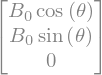

In [276]:
# vector of the untilted magnetic field (expressed in cylindric coordinates)
B_u = B_0 * sym.Matrix([[sym.cos(theta)],[sym.sin(theta)],[0]])
B_u

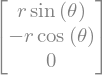

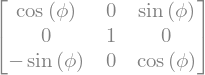

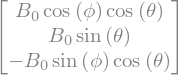

In [289]:
# curve element (expressed in cylindric coordinates)
dl = sym.Matrix([[r*sym.sin(theta)],[-r*sym.cos(theta)],[0]])

# tilt matrix
D = sym.Matrix([[sym.cos(phi),0,sym.sin(phi)],[0,1,0],[-sym.sin(phi),0,sym.cos(phi)]])

# tilted B field
B_t = D * B_u


display(dl)
display(D)
display(B_t)


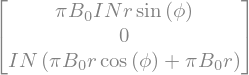

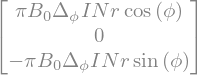

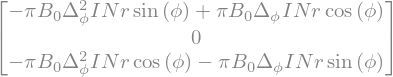

In [305]:
# force on coil, integrated along the whole wire
force = I * N * sym.integrate(dl.cross(B_t),(theta, 0, 2*sym.pi))

# variation of the force as a function of the tilting angle
#     first order
delta_F1 = Delta_phi* sym.diff(force,phi)

delta_F2 = delta_F1 + Delta_phi*sym.diff(delta_F1,phi)

# variation of the force
display(force)
display(delta_F1)
display(delta_F2)

### Numerical evaluation


Force on coil (in N)


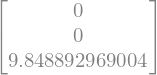


Variation of force (in N): first order


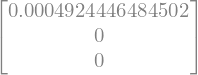

The relative change of force to first order is 0.00


Variation of force (in N): second order


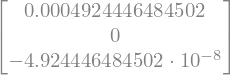

The relative change of force to second order is -5.00E-9


In [324]:
phi_n = 0
Delta_phi_n = 0.1e-3
I_n = 0.01045
B_n = 1
N_n = 1000
r_n = 0.15
specific_force = (force.subs({(phi,phi_n),(B_0,B_n),(I,I_n),(N,N_n),(r,r_n)}))
numeric_force = specific_force.evalf()

specific_delta_F1 = delta_F1.subs(({(phi,phi_n),(B_0,B_n),(I,I_n),(N,N_n),(r,r_n),(Delta_phi,Delta_phi_n)}))
numeric_delta_F1 = specific_delta_F1.evalf()

specific_delta_F2 = delta_F2.subs(({(phi,phi_n),(B_0,B_n),(I,I_n),(N,N_n),(r,r_n),(Delta_phi,Delta_phi_n)}))
numeric_delta_F2 = specific_delta_F2.evalf()

print("Force on coil (in N)")
print("====================")
display(numeric_force)

print()
print("Variation of force (in N): first order") 
print("======================================")
display(numeric_delta_F1)
print(f"The relative change of force to first order is {numeric_delta_F1[2]/numeric_force[2]:.2f}")
print("")
print("")
print("Variation of force (in N): second order")
print("=======================================")
display(numeric_delta_F2)
print(f"The relative change of force to second order is {numeric_delta_F2[2]/numeric_force[2]:.2E}")

###### Variation of the force

### Observations
* To first order, the $z$ component of the force does not vary if coil is horizontal
* To second order, an uncertainty of 1e-3 rad (around perfect verticality) leads to an rel offset of 5e-7; an uncertainty of 0.1e-3 rad misalignment to an offset of 5e-9